In [ ]:
import pandas as pd

# Read the parquet file
df = pd.read_parquet('/home/liliyu/workspace/BAGEL/example_data/bagel_example/t2i/chunk_0.parquet')

# Display the contents
print("Parquet file contents:")
import io
from PIL import Image
import matplotlib.pyplot as plt

# Display first row info
print("First row contents:")
# Sample 5 random indices
n=2
sample_indices = df.sample(n=n).index
for i in sample_indices:
    row = df.iloc[i]
    print("\nText data:")
    print(row['captions'])

    # Convert bytes to image and display
    img_bytes = row['image'] 
    img = Image.open(io.BytesIO(img_bytes))
    print(f"\nImage size: {img.size}")

    # Display the image
    plt.figure(figsize=(10,10))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [1]:
# Read JSONL file
import json
import os

jsonl_path = os.path.expanduser("/home/liliyu/workspace/hf_data/SEED-Data-Edit-Part2-3/real_editing/annotations/split_0001.jsonl")

data = []
with open(jsonl_path, 'r') as f:
    for line in f:
        if line.strip():  # Skip empty lines
            try:
                entry = json.loads(line)
                data.append(entry)
            except json.JSONDecodeError as e:
                print(f"Error decoding line: {e}")
                continue

print(f"Loaded {len(data)} entries from {jsonl_path}")

# Display first few entries
print("\nFirst few entries:")
for i, entry in enumerate(data[:3]):
    print(f"\nEntry {i+1}:")
    print(f"Source: {entry['source_image']}")
    print(f"Target: {entry['target_image']}")
    print(f"Task: {entry['task_type']}")
    print(f"Instruction: {entry['instruction']}")


Loaded 10000 entries from /home/liliyu/workspace/hf_data/SEED-Data-Edit-Part2-3/real_editing/annotations/split_0001.jsonl

First few entries:

Entry 1:
Source: images/0_0.jpg
Target: images/0_1.jpg
Task: ['object-remove', 'background-restore']
Instruction: Delete the person in the blue jacket from the image and then repair the green cloth stage background to center the small dog.

Entry 2:
Source: images/1_0.jpg
Target: images/1_1.jpg
Task: ['overall-adjustment', 'object-isolate']
Instruction: Separate half of the man and the cartoon character, and reassemble them into a new image

Entry 3:
Source: images/2_0.jpg
Target: images/2_1.jpg
Task: ['background-replace', 'object-reposition']
Instruction: Replace the current background with a background with broken walls, place the tiger's head in the hole to emphasize the tiger's head, and add some dust and dirt around the head to make it look more realistic.



Displaying 6 random examples:

Example 1:
Task type: ['object-add', 'overall-saturation-adjustment', 'object-recolor', 'overall-adjustment']
Instruction: Crop off the black edges at the top and bottom of the image, add a sunglasses to the sheep's head, add muscle arms on both sides of the monkey in the back, replace the dog head with a dog head with its mouth open wide, change the green around the monkey's neck to blue, increase the overall saturation, and make the colors more intense.
/home/liliyu/workspace/hf_data/SEED-Data-Edit-Part2-3/real_editing/images/images/2298_0.jpg /home/liliyu/workspace/hf_data/SEED-Data-Edit-Part2-3/real_editing/images/images/2298_1.jpg


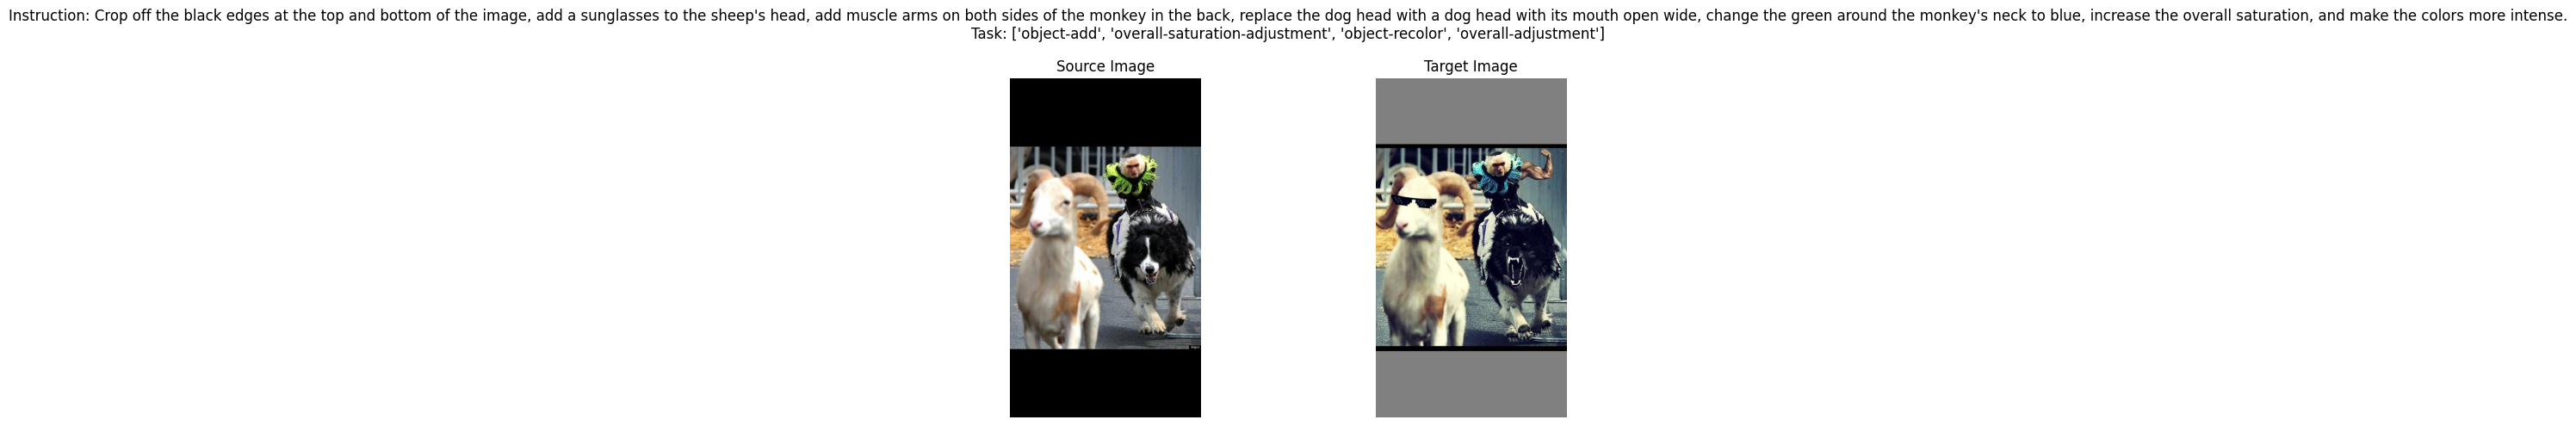


Example 2:
Task type: ['object-add', 'object-replace', 'background-replace']
Instruction: Change the background above to a green Japanese background, change the background below to an outdoor background with chairs, add glasses to the little boy above, and replace the items in both children's hands with different game consoles.
/home/liliyu/workspace/hf_data/SEED-Data-Edit-Part2-3/real_editing/images/images/1919_0.jpg /home/liliyu/workspace/hf_data/SEED-Data-Edit-Part2-3/real_editing/images/images/1919_1.jpg

Example 3:
Task type: ['background-replace', 'object-replace']
Instruction: Keep the character's face, replace the original background with a painting, and replace the face of the close-up character in the painting with the character's face.
/home/liliyu/workspace/hf_data/SEED-Data-Edit-Part2-3/real_editing/images/images/5798_0.jpg /home/liliyu/workspace/hf_data/SEED-Data-Edit-Part2-3/real_editing/images/images/5798_1.jpg

Example 4:
Task type: ['background-remove']
Instruction: 

In [9]:
# Sample and display some examples from filtered data
import random
import matplotlib.pyplot as plt
from PIL import Image

def display_example(entry):
    # Load and display source and target images side by side
    image_dir = "/home/liliyu/workspace/hf_data/SEED-Data-Edit-Part2-3/real_editing/images"
    s_image = os.path.join(image_dir, entry['source_image'])
    t_image = os.path.join(image_dir, entry['target_image'])
    print(s_image, t_image)
    source_img = Image.open(s_image)
    target_img = Image.open(t_image)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
    
    ax1.imshow(source_img)
    ax1.set_title('Source Image')
    ax1.axis('off')
    
    ax2.imshow(target_img)
    ax2.set_title('Target Image') 
    ax2.axis('off')
    
    plt.suptitle(f"Instruction: {entry['instruction']}\nTask: {entry['task_type']}")
    plt.tight_layout()
    plt.show()

# Sample 3 random examples
num_samples = 6
samples = random.sample(data, num_samples)


print(f"\nDisplaying {num_samples} random examples:")
for i, sample in enumerate(samples, 1):
    print(f"\nExample {i}:")
    print(f"Task type: {sample['task_type']}")
    print(f"Instruction: {sample['instruction']}")
    try:
        display_example(sample)
    except:
        pass


In [1]:
# Read JSONL file
import json
import os

jsonl_path = os.path.expanduser("~/workspace/hf_data/SEED-Data-Edit-Part1-Openimages/auto_editing/openimages/annotations/split_0001.jsonl")

data = []
with open(jsonl_path, 'r') as f:
    for line in f:
        if line.strip():  # Skip empty lines
            try:
                entry = json.loads(line)
                data.append(entry)
            except json.JSONDecodeError as e:
                print(f"Error decoding line: {e}")
                continue

print(f"Loaded {len(data)} entries from {jsonl_path}")

# Display first few entries
print("\nFirst few entries:")
for i, entry in enumerate(data[:3]):
    print(f"\nEntry {i+1}:")
    print(f"Source: {entry['source_image']}")
    print(f"Target: {entry['target_image']}")
    print(f"Task: {entry['task_type']}")
    print(f"Instruction: {entry['instruction']}")


Loaded 10000 entries from /home/liliyu/workspace/hf_data/SEED-Data-Edit-Part1-Openimages/auto_editing/openimages/annotations/split_0001.jsonl

First few entries:

Entry 1:
Source: target_images/e0e9e738d26ebce0.jpg
Target: source_images/e0e9e738d26ebce0.jpg
Task: add
Instruction: Insert a glass into the picture.

Entry 2:
Source: target_images/0b415acb33a895d2.jpg
Target: source_images/0b415acb33a895d2.jpg
Task: add
Instruction: Put a white tent to the image, positioned behind the table with food and drinks.

Entry 3:
Source: source_images/9d2fb343560fcf7c.jpg
Target: target_images/9d2fb343560fcf7c.jpg
Task: remove
Instruction: Purge the number 15 from the image.


Total filtered entries with existing images: 12775

Filtered combined JSONL written to: /home/liliyu/workspace/hf_data/SEED-Data-Edit-Part1-Openimages/auto_editing/openimages/annotations_GPT4V/filtered_combined_splits.jsonl

Example 1:
Task type: add
Instruction: Implant a gun to the table next to the knife and ammo.

Example 2:
Task type: add
Instruction: Merge a pair of pants to the image, positioned to the right of the shoes and above the shirt.

Example 3:
Task type: add
Instruction: Incorporate a basket into the photo


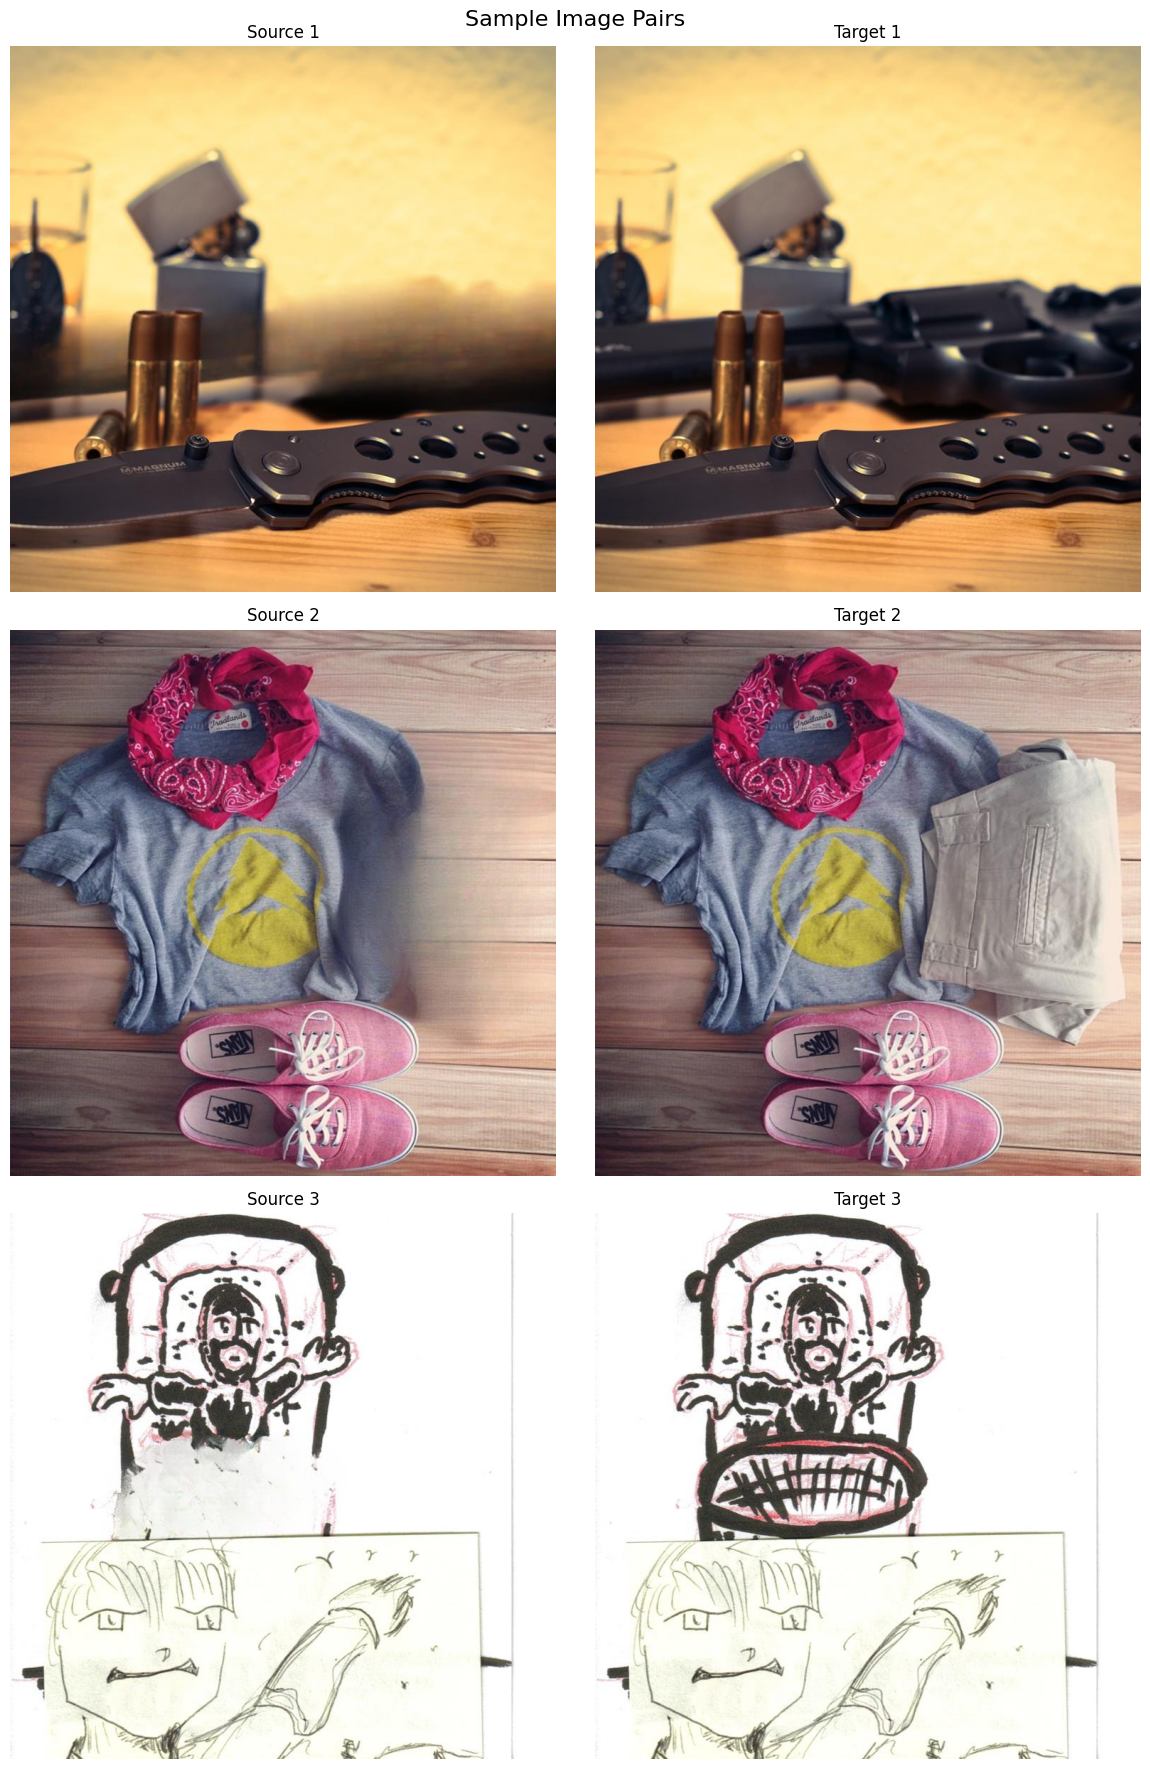

In [3]:
# Check which images actually exist and create filtered JSONL
import os
import json
import random
from PIL import Image
import matplotlib.pyplot as plt

base_dir = os.path.expanduser("~/workspace/hf_data/SEED-Data-Edit-Part1-Openimages/auto_editing/openimages")
annotations_dir = os.path.join(base_dir, "annotations_GPT4V")
image_dir = os.path.join(base_dir, "images")

filtered_data = []

# Process split_0001.jsonl to split_0010.jsonl
for i in range(1, 8):
    jsonl_path = os.path.join(annotations_dir, f"split_{i:04d}.jsonl")
    
    if not os.path.exists(jsonl_path):
        print(f"File not found: {jsonl_path}")
        continue
    
    with open(jsonl_path, 'r') as f:
        for line in f:
            if line.strip():  # Skip empty lines
                try:
                    entry = json.loads(line)
                    
                    # Extract filenames from paths
                    source_file = entry['source_image']
                    target_file = entry['target_image']
                    
                    # Check if both files exist
                    source_path = os.path.join(image_dir, source_file)
                    target_path = os.path.join(image_dir, target_file)
                    
                    if os.path.exists(source_path) and os.path.exists(target_path):
                        # Update paths to use absolute paths
                        entry['source_image'] = os.path.abspath(source_path)
                        entry['target_image'] = os.path.abspath(target_path)
                        filtered_data.append(entry)
                except json.JSONDecodeError as e:
                    print(f"Error decoding line in {jsonl_path}: {e}")
                    continue

print(f"Total filtered entries with existing images: {len(filtered_data)}")

# Write filtered data to new JSONL
output_jsonl = os.path.join(base_dir, "annotations_GPT4V/filtered_combined_splits.jsonl")
with open(output_jsonl, 'w') as f:
    for entry in filtered_data:
        json.dump(entry, f)
        f.write('\n')

print(f"\nFiltered combined JSONL written to: {output_jsonl}")

# Sample and display some examples
num_samples = 3
samples = random.sample(filtered_data, num_samples)

fig, axes = plt.subplots(num_samples, 2, figsize=(12, 6*num_samples))
fig.suptitle("Sample Image Pairs", fontsize=16)

for i, sample in enumerate(samples):
    source_img = Image.open(sample['source_image'])
    target_img = Image.open(sample['target_image'])
    
    axes[i, 0].imshow(source_img)
    axes[i, 0].set_title(f"Source {i+1}")
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(target_img)
    axes[i, 1].set_title(f"Target {i+1}")
    axes[i, 1].axis('off')
    
    print(f"\nExample {i+1}:")
    print(f"Task type: {sample['task_type']}")
    print(f"Instruction: {sample['instruction']}")

plt.tight_layout()
plt.show()
